<a href="https://colab.research.google.com/github/sameerkarur/Data_science/blob/main/06_IITK_AIML_Advanced_Generative_AI/project2_designs/netflix_design_generator_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course-End Project 2: Creating Designs with OpenAI DALL·E & Gradio UI

**Objective:** Build a web platform that generates bespoke banner/poster designs for Netflix-style marketing campaigns from text prompts using OpenAI DALL·E and Gradio.

## Step 1: Install dependencies & set up OpenAI API

In [1]:
%pip install -q openai gradio requests pillow python-dotenv


[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: /Users/sameerkarur/Documents/Git/Data_science/projects/genai_course_end/.venv/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
from getpass import getpass
from io import BytesIO
from pathlib import Path

import gradio as gr
import requests
from openai import OpenAI
from PIL import Image

SECRETS_PATH = Path.home() / "Documents" / "opencareerai-secrets.json"

if not os.environ.get("OPENAI_API_KEY") and SECRETS_PATH.exists():
    with open(SECRETS_PATH, encoding="utf-8") as f:
        secrets = json.load(f)
    os.environ["OPENAI_API_KEY"] = secrets["ai_apis"]["openai_api_key"]
    print("Loaded OPENAI_API_KEY from opencareerai-secrets.json")

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

client = OpenAI()

/Users/sameerkarur/Documents/Git/Data_science/projects/genai_course_end/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded OPENAI_API_KEY from opencareerai-secrets.json


## Step 2: Create `generate_image` function

In [3]:
def generate_image(prompt: str, size: str = "1024x1024"):
    """Generate a marketing design from a text prompt using OpenAI image models."""
    if not prompt or not prompt.strip():
        raise gr.Error("Please enter a text prompt.")

    enhanced_prompt = (
        f"Professional Netflix-style streaming promotional poster design: {prompt.strip()}. "
        "Cinematic lighting, bold typography space, high contrast, modern digital marketing banner."
    )

    response = client.images.generate(
        model="gpt-image-1",
        prompt=enhanced_prompt,
        n=1,
        size=size,
    )

    item = response.data[0]
    if item.url:
        image_bytes = requests.get(item.url, timeout=60).content
    else:
        import base64
        image_bytes = base64.b64decode(item.b64_json)

    image = Image.open(BytesIO(image_bytes))
    return image

## Step 3: Build and launch Gradio interface

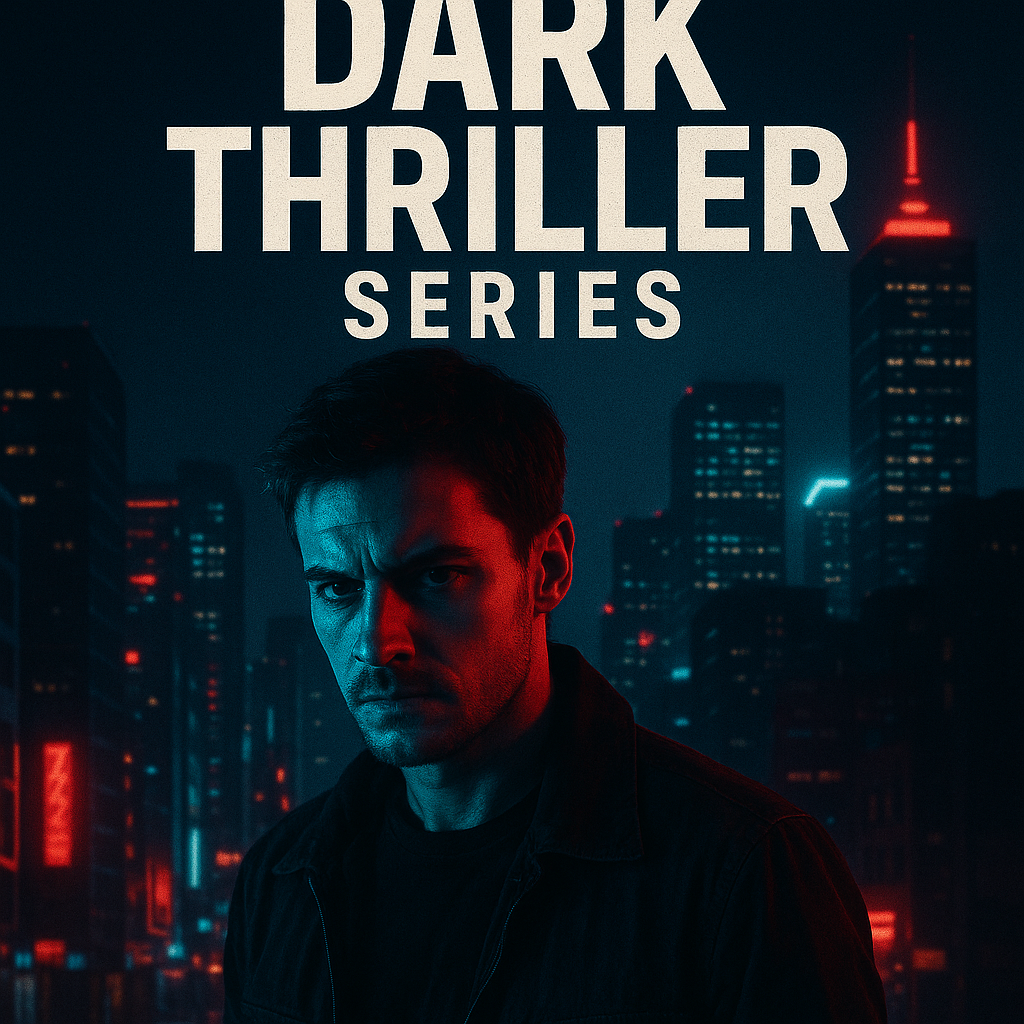

In [4]:
demo = gr.Interface(
    fn=generate_image,
    inputs=[
        gr.Textbox(
            label="Design Prompt",
            placeholder="A dark thriller series poster with neon city skyline and mysterious silhouette",
            lines=3,
        ),
        gr.Dropdown(
            choices=["1024x1024", "1024x1536", "1536x1024"],
            value="1024x1024",
            label="Image Size",
        ),
    ],
    outputs=gr.Image(label="Generated Design", type="pil"),
    title="Netflix Campaign Design Generator",
    description=(
        "Enter a text prompt to generate bespoke banner/poster designs for digital marketing campaigns "
        "using OpenAI image generation and Gradio."
    ),
    examples=[
        ["Dark thriller series poster with neon city skyline and mysterious silhouette", "1024x1024"],
        ["Romantic drama series poster with couple under rain and warm city lights", "1024x1024"],
        ["Action movie banner with explosion, hero silhouette, and bold red-black theme", "1024x1024"],
    ],
)

# Test generation (for notebook execution)
test_image = generate_image("Dark thriller series poster with neon city skyline")
test_image

### Launch Gradio UI (run locally for screenshots)

Uncomment and run the cell below to open the design generator in your browser.

In [5]:
# demo.launch(share=False)

## Conclusion

This notebook demonstrates:
- Text-to-image generation with OpenAI DALL·E
- HTTP fetch + PIL image handling
- A Gradio web UI for creative design workflows in digital marketing